Write a module that converts heatmap into points.

Steps:


    1) local maximums with maxpool2d
    2) threshold filter
    3) merge points closer than sigma
    4) refine by fitting 2d gaussian

Then some function to compare with GT points. For that loop that finds closest GT point?



In [1]:
import yaml
import cv2

from pathlib import Path
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from datasets.bcdata import BCDataDataset, collate_heatmap_points
from datasets.transforms import PointsToLocalizationHeatmap

from visualization import overlay_heatmap
from training import train
from models import HybridModel, heatmap_weighted_mse_loss
from utils.debug import print_info

from src.points_v2 import heatmaps_to_points_batch
from src.evaluation import count_metrics


import torch
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

In [2]:
with open("config.yaml", "r") as f:
    cfg = yaml.safe_load(f)

# paths:  hpvictus_paths collab_paths h200_paths
data_root = Path(cfg["h200_paths"]["data_root"])
print(data_root)

/raid/datasets/Yeldos/BCData


In [3]:
heatmap_generator = PointsToLocalizationHeatmap(out_hw=(160,160), in_hw=(640,640), sigma=2.0)

In [4]:
dataset = BCDataDataset(root = data_root,
                        split="train",
                        target_transform = heatmap_generator)

In [5]:
train_loader = DataLoader(
    dataset,
    batch_size=1,        # choose based on GPU memory (640×640 images are large)
    shuffle=True,
    num_workers=0,       # use 0 if debugging
    pin_memory=True,     # recommended when using GPU
    drop_last=True,       # optional, useful for BatchNorm
    collate_fn = collate_heatmap_points
)

Supposed to get metrics using model output heatmap and ground truth points.

Test on generated from GT heatmaps.

In [6]:
model = HybridModel()

if torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'
print(f"device: {device}")

device: cuda


In [7]:
'''
count: (B, 2)
pos_points_batch:   (N_pos, 2)
:    (N_neg, 2)

'''


image_batch, heatmaps_batch, pos_points_batch, neg_points_batch = next(iter(train_loader))

image_batch.to(device)
heatmaps_batch.to(device)


loc_hm, den_hm, count = model(image_batch)

# compute loss, backward, make step

count_metrics(count, pos_points_batch, neg_points_batch)




********************
count: torch.Tensor | shape=(1, 2) | dtype=torch.float32 | device=cpu
********************


********************
pos_points_batch: list | len=1

********************
pos_points_batch  [0] : torch.Tensor | shape=(31, 2) | dtype=torch.float32 | device=cpu
********************

********************


********************
neg_points_batch: list | len=1

********************
neg_points_batch  [0] : torch.Tensor | shape=(41, 2) | dtype=torch.float32 | device=cpu
********************

********************



In [8]:
count

tensor([[ 1182.9999, -1262.8972]], grad_fn=<CatBackward0>)

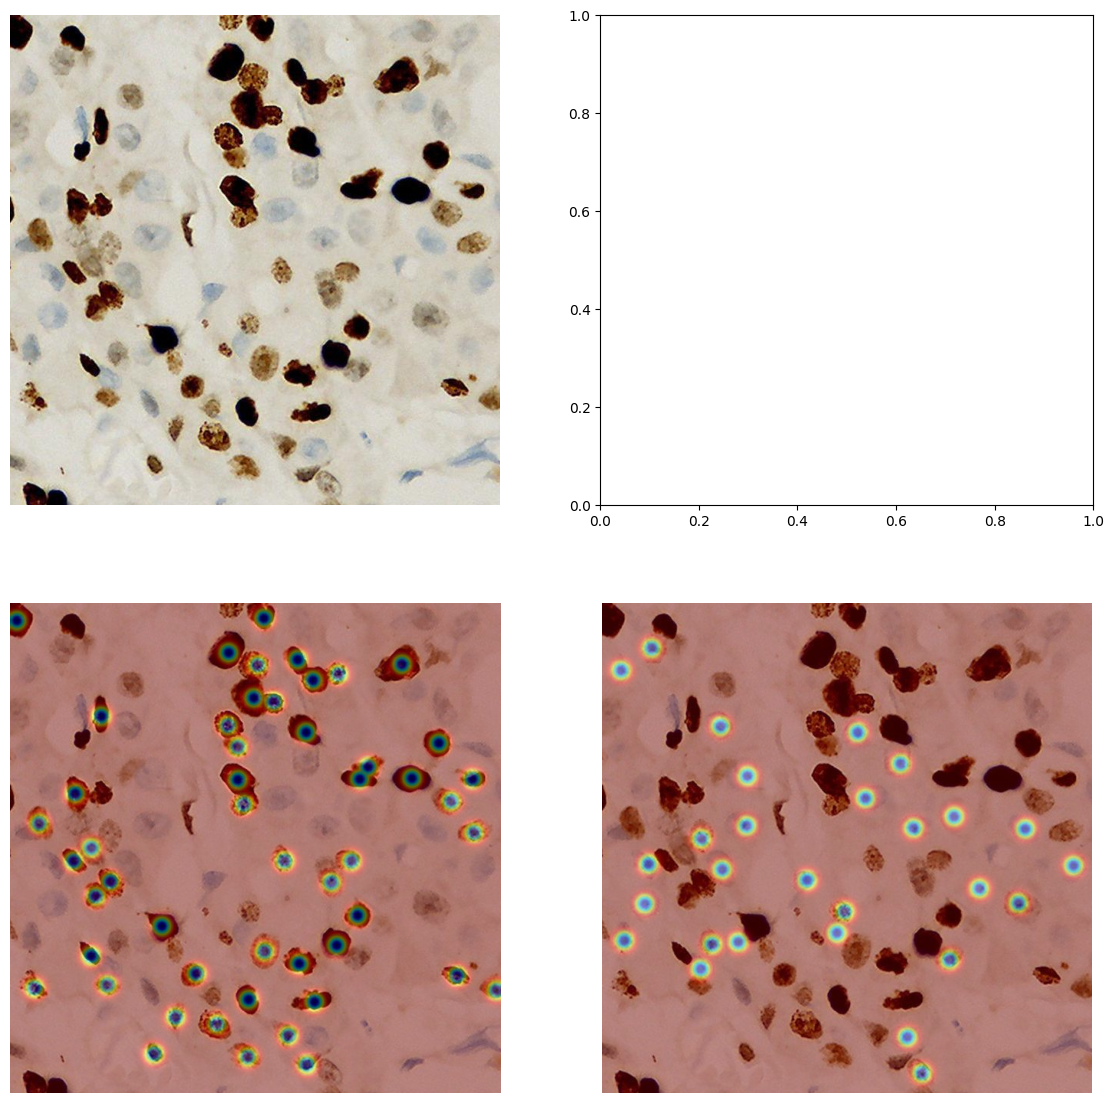

In [8]:
image, heatmaps, pos_points, neg_points = dataset[0]
overlay_heatmap(image, heatmaps, alpha=0.4)


In [9]:
image.shape

torch.Size([3, 640, 640])

True

In [ ]:
# image_batch, heatmaps_batch, pos_points_batch, neg_points_batch

#out_pos, out_neg = heatmaps_to_points_batch(heatmaps_batch, kernel_size=5, threshold = 0.9)

In [11]:
print_info(out_pos, 'rec pos|')
print_info(pos_points_batch, 'orig pos')


********************
rec pos|: list | len=1

********************
rec pos|  [0] : torch.Tensor | shape=(113, 2) | dtype=torch.float32 | device=cpu
********************

********************


********************
orig pos: list | len=1

********************
orig pos  [0] : torch.Tensor | shape=(113, 2) | dtype=torch.float32 | device=cpu
********************

********************



In [12]:
print_info(out_neg, 'rec neg')
print_info(neg_points_batch, 'orig neg')



********************
rec neg: list | len=1

********************
rec neg  [0] : torch.Tensor | shape=(90, 2) | dtype=torch.float32 | device=cpu
********************

********************


********************
orig neg: list | len=1

********************
orig neg  [0] : torch.Tensor | shape=(90, 2) | dtype=torch.float32 | device=cpu
********************

********************



In [7]:
from scipy.optimize import linear_sum_assignment

row_ind, col_ind = linear_sum_assignment(C_thr)
costs = C_thr[row_ind, col_ind]

valid = costs < INF

matched_pred = row_ind[valid]
matched_gt = col_ind[valid]

unmatched_pred = np.setdiff1d(np.arange(pred_neg_pts[0].shape[0]), matched_pred)
unmatched_gt = np.setdiff1d(np.arange(neg_points[0].shape[0]), matched_gt)


TP_count = len(matched_pred)
FP_count = len(unmatched_pred)
FN_count = len(unmatched_gt)

NameError: name 'C_thr' is not defined